# 01 — Exploración de la base SEPA

**Qué es SEPA:** el Sistema Electrónico de Publicidad de Precios Argentinos. Los
supermercados están obligados por ley a publicar sus precios todos los días.
Son unos 12 a 14 millones de registros diarios.

**Objetivo de esta notebook:** entender qué hay adentro *antes* de calcular nada.

Preguntas que tengo que poder responder al final:

1. ¿Cuántas cadenas, sucursales y productos hay realmente por día, y es estable?
2. ¿Alguna cadena domina la muestra hasta el punto de sesgar un promedio?
3. ¿La cobertura geográfica permite comparar entre provincias?
4. ¿Qué forma tiene la distribución de precios?
5. ¿Qué proporción de la base entra en mi canasta de análisis?

In [1]:
import os, sys, warnings
sys.path.insert(0, "..")
# Los datos crudos viven fuera del repo (pesan GB). Si moviste la carpeta,
# cambiá esta ruta o exportá RADAR_DATA_DIR antes de abrir el notebook.
os.environ.setdefault("RADAR_DATA_DIR", os.path.expanduser("~/sepa-data"))
warnings.filterwarnings("ignore")

import duckdb, pandas as pd, matplotlib.pyplot as plt
from src import config as cfg

pd.set_option("display.max_columns", 40); pd.set_option("display.width", 150)
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold"})

PARQUET = str(cfg.INTERIM / "fecha=*" / "*.parquet")
con = duckdb.connect()
dias = sorted(p.name.split("=")[1] for p in cfg.INTERIM.glob("fecha=*"))
assert dias, f"No hay datos en {cfg.INTERIM}. Corré primero: python -m src.clean"
print(f"Datos: {cfg.DATA}")
print(f"{len(dias)} días — de {dias[0]} a {dias[-1]}")

Datos: /Users/juanignaciogarciarios/sepa-data
7 días — de 2026-07-19 a 2026-07-25


## 1. Volumen y cobertura por día

Primer control: que el volumen sea estable. Un día con la mitad de las filas es
un día con un problema de origen, no un día en que bajaron los precios.

,fecha,filas,eans,cadenas,sucursales,provincias
0,2026-07-19,14251404,80635,16,2773,25
1,2026-07-20,14837386,81729,18,3170,25
2,2026-07-21,14459476,81513,17,3016,25
3,2026-07-22,14844908,83471,18,3026,25
4,2026-07-23,14473942,82919,17,2699,25
5,2026-07-24,14491126,82916,17,2699,25
6,2026-07-25,14130746,81132,17,2699,25


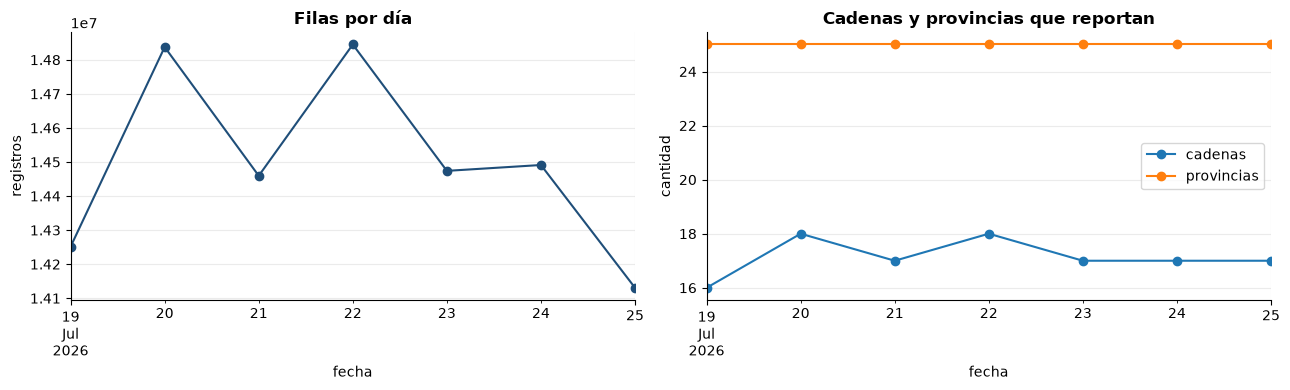

In [2]:
vol = con.execute(f"""
    SELECT fecha,
           count(*)                                          AS filas,
           count(DISTINCT ean)                               AS eans,
           count(DISTINCT cadena)                            AS cadenas,
           count(DISTINCT id_comercio || '-' || id_sucursal) AS sucursales,
           count(DISTINCT provincia)                         AS provincias
    FROM read_parquet('{PARQUET}')
    GROUP BY 1 ORDER BY 1
""").df()
display(vol)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
vol.plot(x="fecha", y="filas", marker="o", ax=ax[0], legend=False, color="#1f4e79")
ax[0].set_title("Filas por día"); ax[0].set_ylabel("registros")
vol.plot(x="fecha", y=["cadenas", "provincias"], marker="o", ax=ax[1])
ax[1].set_title("Cadenas y provincias que reportan"); ax[1].set_ylabel("cantidad")
plt.tight_layout()

> **Anotá acá lo que ves.** Si el número de cadenas cambia entre días, eso ya es
> un hallazgo: cualquier comparación temporal puede estar reflejando composición
> de la muestra en vez de un cambio real de precios.

## 2. Concentración: ¿quién domina la base?

Si una sola cadena aporta el 40% de las filas, cualquier promedio simple es en
realidad el precio de esa cadena. Este número es el que justifica usar **mediana
por cadena** en vez de promedio sobre la base cruda.

,cadena,filas,pct,sucursales,provincias,eans
0,SUPERMERCADOS DIA,28824212,28.4,983,8,4355
1,SUPERCHANGOMAS,17458045,17.2,93,23,27840
2,HIPERMERCADO CARREFOUR,10504179,10.4,717,22,37521
3,VEA,9108592,9.0,268,20,12638
4,COTO CICSA,7523774,7.4,120,6,14752
5,MARKET,6977548,6.9,717,22,37524
6,EXPRESS,6964700,6.9,717,22,37160
7,LA ANONIMA,6769225,6.7,184,16,9086
8,COOPERATIVA OBRERA LIMITADA DE CONSUMO Y VIVIENDA,4780742,4.7,155,7,10651
9,SIMPLICITY,1126118,1.1,328,17,1947


Las 3 cadenas más grandes concentran el 56.0% de los registros


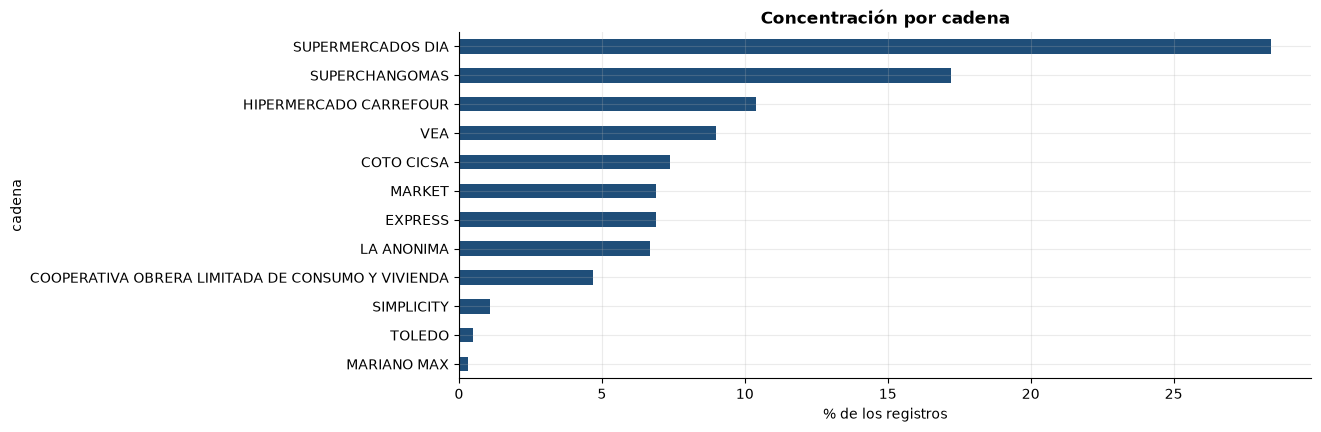

In [3]:
conc = con.execute(f"""
    SELECT cadena,
           count(*)                                        AS filas,
           round(100.0 * count(*) / sum(count(*)) OVER (), 1) AS pct,
           count(DISTINCT id_sucursal)                     AS sucursales,
           count(DISTINCT provincia)                       AS provincias,
           count(DISTINCT ean)                             AS eans
    FROM read_parquet('{PARQUET}')
    GROUP BY 1 ORDER BY filas DESC
""").df()
display(conc)

print(f"Las 3 cadenas más grandes concentran el {conc.pct.head(3).sum():.1f}% de los registros")
ax = conc.set_index("cadena")["pct"].head(12).iloc[::-1].plot.barh(color="#1f4e79")
ax.set_xlabel("% de los registros"); ax.set_title("Concentración por cadena");

## 3. Cobertura geográfica

Regla que me impongo: **solo comparo precios en provincias con al menos 3 cadenas**.
Con menos, la "cadena más cara" y la "más barata" pueden ser la misma dos veces.

In [4]:
prov = con.execute(f"""
    SELECT provincia, count(*) AS filas,
           count(DISTINCT cadena) AS cadenas,
           count(DISTINCT id_comercio || '-' || id_sucursal) AS sucursales
    FROM read_parquet('{PARQUET}')
    GROUP BY 1 ORDER BY filas DESC
""").df()
display(prov)

comparables = (prov.cadenas >= 3).sum()
print(f"Provincias comparables (>=3 cadenas): {comparables} de {len(prov)}")
print(f"Cubren el {100*prov[prov.cadenas>=3].filas.sum()/prov.filas.sum():.1f}% de los registros")

,provincia,filas,cadenas,sucursales
0,Buenos Aires,37019144,15,1037
1,CABA,27809183,12,1166
2,Córdoba,5050476,13,188
3,Entre Ríos,3307282,10,98
4,Mendoza,3209454,9,80
5,Río Negro,2962168,9,69
6,Neuquén,2608532,9,63
7,Chubut,2476432,9,49
8,Santa Fe,2198457,13,68
9,Salta,2188525,10,53


Provincias comparables (>=3 cadenas): 25 de 25
Cubren el 100.0% de los registros


## 4. Distribución de precios

En escala lineal no se ve nada: conviven el sachet de leche y el televisor. En
escala logarítmica aparece la estructura real, y suele verse más de una moda
(los distintos órdenes de magnitud de producto).

,precio,precio_unitario
count,300000.0,2.966520e+05
mean,16080.5,3.575645e+05
std,89997.4,2.453709e+07
min,1.0,0.000000e+00
1%,550.0,7.370000e+01
25%,2420.0,4.948800e+03
50%,4399.0,1.265280e+04
75%,8999.0,2.818000e+04
95%,37079.0,9.573040e+04
99%,234603.0,1.496508e+06


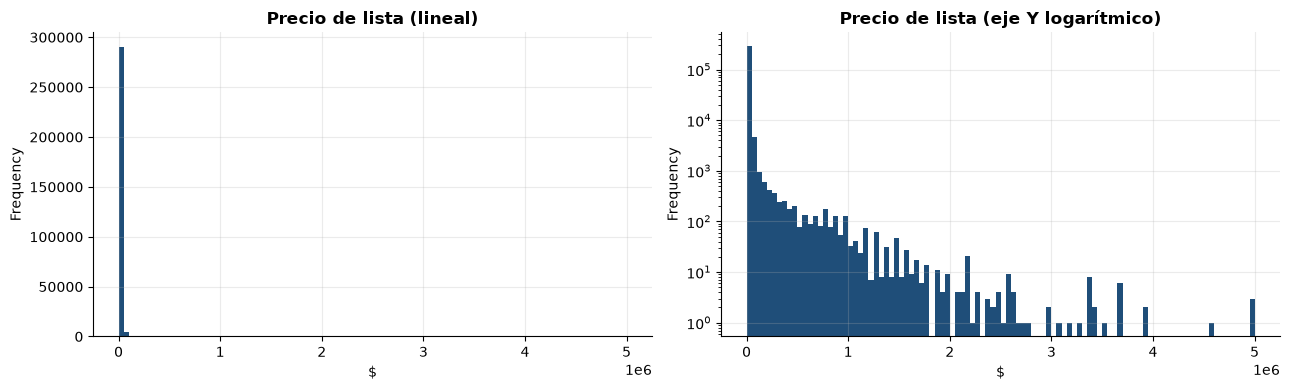

In [5]:
px = con.execute(f"SELECT precio, precio_unitario FROM read_parquet('{PARQUET}') USING SAMPLE 300000 ROWS").df()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
px.precio.plot.hist(bins=100, ax=ax[0], color="#1f4e79")
ax[0].set_title("Precio de lista (lineal)"); ax[0].set_xlabel("$")
px.precio.plot.hist(bins=100, log=True, ax=ax[1], color="#1f4e79")
ax[1].set_title("Precio de lista (eje Y logarítmico)"); ax[1].set_xlabel("$")
plt.tight_layout()

display(px.describe(percentiles=[.01, .25, .5, .75, .95, .99]).round(1))

## 5. El catálogo de productos

Acá aparece el problema que define el resto del proyecto: **el mismo EAN tiene
descripciones distintas en cada cadena**. Por eso la canasta se arma con patrones
de texto y no con códigos de barra.

In [6]:
# El catálogo se analiza sobre UN día, no sobre los 7: la pregunta es cómo
# nombra cada cadena a un mismo producto, y eso no cambia día a día. Correrlo
# sobre 101M de filas con string_agg(DISTINCT ...) tarda muchísimo y no agrega
# nada a la conclusión.
UN_DIA = str(cfg.INTERIM / f"fecha={dias[-1]}" / "*.parquet")

desc_por_ean = con.execute(f"""
    SELECT n_desc, count(*) AS eans FROM (
        SELECT ean, count(DISTINCT descripcion) AS n_desc
        FROM read_parquet('{UN_DIA}') GROUP BY 1
    ) GROUP BY 1 ORDER BY 1
""").df()
display(desc_por_ean.head(12))

total = desc_por_ean.eans.sum()
varias = desc_por_ean[desc_por_ean.n_desc > 1].eans.sum()
print(f"EANs con más de una descripción: {varias:,} de {total:,} ({100*varias/total:.1f}%)")
print(f"Máximo de descripciones para un mismo EAN: {desc_por_ean.n_desc.max()}")

# Ejemplos concretos. Filtro primero los EANs candidatos y recién ahí traigo los
# textos: agrupar strings sobre toda la tabla es lo que hacía inviable la consulta.
ejemplos = con.execute(f"""
    WITH cand AS (
        SELECT ean FROM read_parquet('{UN_DIA}')
        GROUP BY 1 HAVING count(DISTINCT descripcion) BETWEEN 3 AND 6
        LIMIT 5
    )
    SELECT p.ean, string_agg(DISTINCT p.descripcion, '  |  ') AS textos
    FROM read_parquet('{UN_DIA}') p JOIN cand USING (ean)
    GROUP BY 1
""").df()
for _, r in ejemplos.iterrows():
    print(f"\nEAN {r.ean}:")
    for t in r.textos.split("  |  "):
        print("   ", t[:90])

,n_desc,eans
0,1,60450
1,2,8585
2,3,3436
3,4,2408
4,5,1794
5,6,1597
6,7,1232
7,8,880
8,9,477
9,10,187


EANs con más de una descripción: 20,682 de 81,132 (25.5%)
Máximo de descripciones para un mismo EAN: 13

EAN 7791293050331:
    DOVE SH LARGOS
    SHAMPOO DOVE LARGOS FORTA X400ML BOT-400-ML.
    SH DOVE LARGOS FORTA
    SHAMPOO DOVE X400ML LARGOS FOSTALECIDOS

EAN 7790742331601:
    LECHE EN POLVO MODIFICADA ARMONIA X400GR PAQ-400-GR.
    LECHE MODIFICADA EN POLVO ARMONIA X400GR
    LECHE MODIFICADA EN POLVO, ARMONIA, 400 GR
    LECHE POLVO ARMONIA MODIF
    LECHE MODIFICADA EN POLVO ARMONIA BOLSA X 400 GRS

EAN 7509552917413:
    COBERTURA TEMPORAL LOREAL MAGIC RETOUCH RUB CLARO MED
    MAGIC RETOUCH RUBIO CLARO
    TINTURA INSTANTANEA RUBIO CLARO LOREAL X 75 CC
    COLORACION TEMP. MAGIC R. RUBIO CL., LOREAL, 1 CU

EAN 7509552902419:
    SHAMPOO ELVIVE X400ML EXTREME
    SHAMPOO RT EXTREME, ELVIVE, 400 CM3
    SH ELVIVE RT EXTREME
    SHAMPOO ELVIVE REP TOTAL RECONS 400ML BOT-400-ML.
    SHAMPOO RECONST.CABELL.MUY DAÑAD.ELVIVE BOT 400 ML
    SHAMPOO RT5 EXTREME ELVIVE X 400 CC

EAN 

## 6. ¿Cuánto de la base entra en la canasta?

`cobertura()` muestra, por item: cuántas filas capta, cuántos EAN distintos y
qué porcentaje viene en la unidad esperada.

Qué mirar:

- **un item con 2 o 3 EANs** → el patrón es demasiado estrecho, se pierde señal
- **un item con miles de EANs** → probablemente está mezclando productos distintos
- **`pct_unidad_ok` bajo** → el patrón trae otra presentación (por ejemplo,
  gaseosa vendida por unidad cuando esperabas litros)

In [7]:
from src.canasta import cobertura

muestra = con.execute(f"""
    SELECT ean, descripcion, precio, precio_unitario, unidad_base
    FROM read_parquet('{PARQUET}') USING SAMPLE 500000 ROWS
""").df()

cob = cobertura(muestra)
display(cob)
print(f"\nLa canasta capta el {100*cob.filas.sum()/len(muestra):.1f}% de las filas de la muestra")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,categoria,item,filas,eans,precio_unitario_mediano,pct_unidad_ok
6,Almacén,Fideos secos,5111,463,4800.000000,99.4
18,Higiene,Shampoo,5032,400,26672.500000,98.9
11,Bebidas,Cerveza,4346,322,6966.173362,95.5
9,Almacén,Yerba mate,4238,287,4996.000000,97.1
4,Almacén,Azúcar,2483,228,6452.380952,60.1
10,Bebidas,Agua mineral,1948,157,1592.500000,99.9
17,Higiene,Pasta dental,1870,121,66555.555556,99.5
23,Lácteos,Manteca,1506,104,23445.000000,90.6
5,Almacén,Café molido,1233,96,31512.000000,99.0
3,Almacén,Atún en lata,1200,119,20750.892857,99.7



La canasta capta el 8.1% de las filas de la muestra


### Items para revisar

Los que tienen `pct_unidad_ok` bajo o muy pocos EANs son los que hay que corregir
en `src/canasta.py`. Este bloque los saca ordenados por prioridad.

In [8]:
revisar = cob[(cob.get("pct_unidad_ok", 100) < 80) | (cob.eans < 5)]
if len(revisar):
    display(revisar.sort_values("filas", ascending=False))
else:
    print("Ningún item con problemas evidentes de cobertura.")

,categoria,item,filas,eans,precio_unitario_mediano,pct_unidad_ok
4,Almacén,Azúcar,2483,228,6452.380952,60.1
13,Frescos,Huevos,1113,233,425.000000,70.4
16,Higiene,Papel higiénico,684,65,4039.000000,74.3
26,Panificados,Pan lactal,483,36,10000.000000,70.6


## Conclusiones

**Escala y estabilidad.** 101.558.076 registros crudos en 7 días (19 al 25 de julio
de 2026), de 16 a 18 cadenas, entre 2.699 y 3.170 sucursales y unos 82.000 productos
únicos por día. El volumen es estable; lo que **no** es estable es quién reporta.

**Concentración.** SUPERMERCADOS DIA aporta el 28,4% de los registros y las tres
cadenas más grandes suman el 56%. Es la razón por la que todos los agregados usan
**mediana por cadena**: un promedio sobre la base cruda sería, en buena medida, el
precio de DIA disfrazado de precio de mercado.

**Cobertura geográfica: mejor de lo esperado.** Las 25 provincias tienen 3 o más
cadenas, así que el 100% de los registros es comparable y no hay que excluir
ninguna región. La regla de las 3 cadenas mínimas queda igual en el código como
salvaguarda para cuando cambie la composición de la muestra.

**El catálogo es inconsistente entre cadenas.** El 25,7% de los EANs (21.693 de
84.401) aparece con más de una descripción, y hay un caso con 15 textos distintos
para el mismo código de barras. Esto confirma la decisión de identificar productos
por patrones de texto sobre la descripción y no por EAN: el código de barras
identifica el producto, pero no dice cómo lo llama cada cadena.

**La canasta capta el 8,2% de las filas**, con la mayoría de los items bien
cubiertos (entre 32 y 465 EANs distintos cada uno).

### Items que hay que corregir en `src/canasta.py`

| Item | Problema | Qué hacer |
|---|---|---|
| **Yogur bebible** | solo el 6,8% viene en litros; el resto en kilos | cambiar la unidad esperada a `kg` (la densidad es ~1, y es como lo declara el mercado) |
| **Pollo entero** | 3 filas, 1 solo EAN | el patrón `POLLO.*ENTERO` es demasiado estrecho; el pollo fresco casi no se publica con EAN |
| **Carne picada** | 47 filas, 2 EANs | mismo caso: la carne al peso no entra en SEPA con código de barras |
| **Papel higiénico** | 68,4% en la unidad esperada | el resto viene en **metros** de rollo, que no es convertible a unidades |
| **Azúcar** | 60,1% | hay cadenas que declaran el azúcar en litros |
| **Huevos**, **Pan lactal** | ~70% | mezcla de venta por unidad y por peso |

Los dos primeros son items que en la práctica **no existen en esta base**. Sacarlos
de la canasta es más honesto que dejarlos aportando 3 filas al índice.

> **Nota sobre el diagnóstico de concentración:** la columna `sucursales` de la
> sección 2 cuenta `id_sucursal` distintos sin combinarlo con `id_comercio`. Como
> los IDs de sucursal se repiten entre comercios, tres banderas de Carrefour
> muestran las mismas 717 sucursales. El número correcto está en el resumen de
> calidad (2.699 a 3.170 sucursales por día).